In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from keras.datasets import mnist

(X_train, y_train), (X_test, y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [3]:
print("Training images shape:", X_train.shape)
print("Training labels shape:", y_train.shape)

print("Test images shape:", X_test.shape)
print("Test labels shape:", y_test.shape)

Training images shape: (60000, 28, 28)
Training labels shape: (60000,)
Test images shape: (10000, 28, 28)
Test labels shape: (10000,)


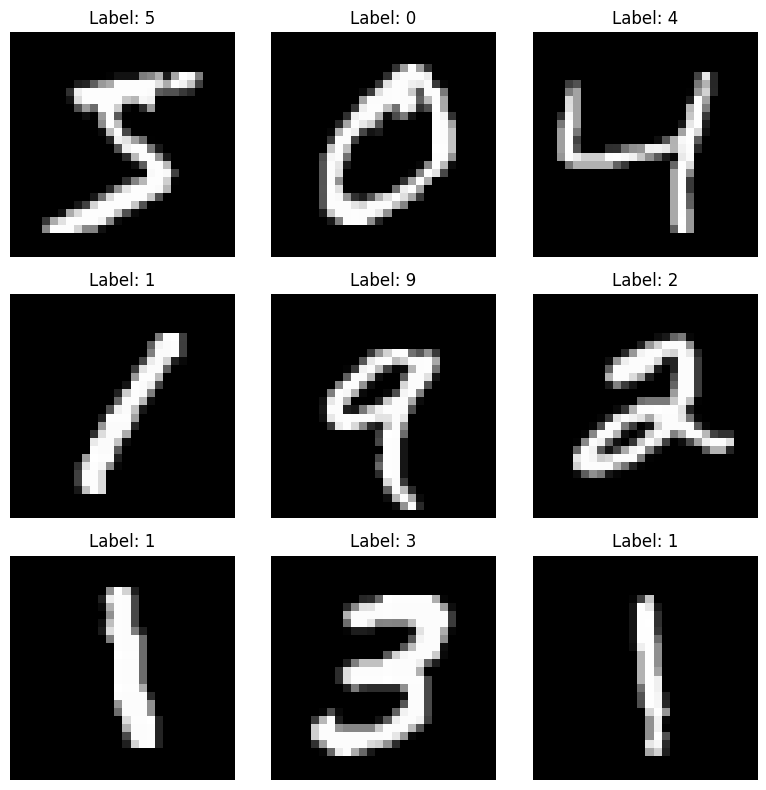

In [4]:
plt.figure(figsize=(8,8))

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(X_train[i], cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')

plt.tight_layout()
plt.show()

In [5]:
#Scale the values
X_train = X_train.astype(np.float32) / 255.0
X_test = X_test.astype(np.float32) / 255.0

In [6]:
#Flatten the Image as MLP Input layer expects 28x28=784
X_train = X_train.reshape(-1, 784)
X_test = X_test.reshape(-1, 784)
print(X_train.shape)
print(X_test.shape)

(60000, 784)
(10000, 784)


In [7]:
def one_hot(y, num_classes=10):
    onehot = np.zeros((y.shape[0], num_classes))
    onehot[np.arange(y.shape[0]), y] = 1
    return onehot

In [8]:
Y_train = one_hot(y_train)
Y_test = one_hot(y_test)

In [9]:
print("Original label:", y_train[0])
print("One-hot:", Y_train[0])

Original label: 5
One-hot: [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]


In [10]:
np.random.seed(42)

# Input -> Hidden
W1 = np.random.randn(784, 128) * np.sqrt(2.0 / 784)
b1 = np.zeros((1, 128))

# Hidden -> Output
W2 = np.random.randn(128, 10) * np.sqrt(2.0 / 128)
b2 = np.zeros((1, 10))

In [11]:
print("W1:", W1.shape)
print("b1:", b1.shape)

print("W2:", W2.shape)
print("b2:", b2.shape)

W1: (784, 128)
b1: (1, 128)
W2: (128, 10)
b2: (1, 10)


Define ReLU

In [12]:
def relu(x):
    return np.maximum(0, x)

In [13]:
def relu_derivative(x):
    return (x > 0).astype(float)

Define Softmax

In [14]:
def softmax(x):

    exp_x = np.exp(x - np.max(x, axis=1, keepdims=True))

    return exp_x / np.sum(exp_x, axis=1, keepdims=True)

Forward Pass

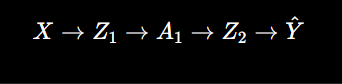




A1-> ReLU
Y->Softmax

In [15]:
def forward(X):
    global Z1, A1, Z2, A2
    # Layer 1
    Z1 = X @ W1 + b1
    A1 = relu(Z1)
    # Output layer
    Z2 = A1 @ W2 + b2
    A2 = softmax(Z2)
    return A2

In [16]:
sample_output = forward(X_train[:5])

print(sample_output.shape)
print(sample_output[0])

(5, 10)
[0.14479961 0.0925005  0.09725679 0.04483728 0.06972212 0.13210605
 0.0556922  0.14834432 0.07805109 0.13669003]


In [17]:
print(np.sum(sample_output[0]))

0.9999999999999999


Cross Entropy

Loss Function

In [18]:
def cross_entropy(y_true, y_pred):
    epsilon = 1e-12
    y_pred = np.clip(y_pred, epsilon, 1.0 - epsilon)
    loss = -np.mean(np.sum(y_true * np.log(y_pred), axis=1))
    return loss

In [19]:
output = forward(X_train[:5])
loss = cross_entropy(Y_train[:5], output)
print(loss)

2.3268776163629936


Backward Pass

In [20]:
def backward(X, Y, output, learning_rate):
    global W1, b1, W2, b2
    m = X.shape[0]
    dZ2 = output - Y
    dW2 = (A1.T @ dZ2)/m
    db2 = np.sum(dZ2, axis=0, keepdims=True)/m
    dA1 = dZ2 @ W2.T
    dZ1 = dA1 * relu_derivative(Z1)
    dW1 = (X.T @ dZ1)/m
    db1 = np.sum(dZ1, axis=0, keepdims=True)/m
    W1 -= learning_rate * dW1
    b1 -= learning_rate * db1
    W2 -= learning_rate * dW2
    b2 -= learning_rate * db2

In [21]:
output = forward(X_train[:64])

loss_before = cross_entropy(Y_train[:64], output)

backward(X_train[:64], Y_train[:64], output, 0.01)

output_after = forward(X_train[:64])

loss_after = cross_entropy(Y_train[:64], output_after)

print("Loss before:", loss_before)
print("Loss after :", loss_after)

Loss before: 2.4678857839296464
Loss after : 2.4411824773175117


Accuracy Function

In [22]:
def accuracy(X, y):

    probs = forward(X)

    predictions = np.argmax(probs, axis=1)

    return np.mean(predictions == y)

Train Hyper Parameters

In [23]:
epochs = 20
batch_size = 64
learning_rate = 0.1
losses = []

Training Loop- The model is run for 20 epochs

In [24]:
num_samples = X_train.shape[0]

for epoch in range(epochs):

    indices = np.random.permutation(num_samples)

    X_shuffled = X_train[indices]
    Y_shuffled = Y_train[indices]

    epoch_loss = 0

    for i in range(0, num_samples, batch_size):

        X_batch = X_shuffled[i:i+batch_size]
        Y_batch = Y_shuffled[i:i+batch_size]

        # Forward
        output = forward(X_batch)

        # Loss
        loss = cross_entropy(Y_batch, output)
        epoch_loss += loss

        # Backward
        backward(X_batch, Y_batch, output, learning_rate)

    avg_loss = epoch_loss / (num_samples // batch_size)

    losses.append(avg_loss)

    # Accuracy on ORIGINAL data
    train_acc = accuracy(X_train[:5000], y_train[:5000])

    print(
        f"Epoch {epoch+1}/{epochs} | "
        f"Loss: {avg_loss:.4f} | "
        f"Train Acc: {train_acc:.4f}"
    )

Epoch 1/20 | Loss: 0.3746 | Train Acc: 0.9416
Epoch 2/20 | Loss: 0.1992 | Train Acc: 0.9598
Epoch 3/20 | Loss: 0.1484 | Train Acc: 0.9708
Epoch 4/20 | Loss: 0.1192 | Train Acc: 0.9760
Epoch 5/20 | Loss: 0.1004 | Train Acc: 0.9800
Epoch 6/20 | Loss: 0.0864 | Train Acc: 0.9790
Epoch 7/20 | Loss: 0.0761 | Train Acc: 0.9822
Epoch 8/20 | Loss: 0.0681 | Train Acc: 0.9874
Epoch 9/20 | Loss: 0.0609 | Train Acc: 0.9868
Epoch 10/20 | Loss: 0.0559 | Train Acc: 0.9894
Epoch 11/20 | Loss: 0.0504 | Train Acc: 0.9876
Epoch 12/20 | Loss: 0.0464 | Train Acc: 0.9912
Epoch 13/20 | Loss: 0.0428 | Train Acc: 0.9928
Epoch 14/20 | Loss: 0.0385 | Train Acc: 0.9926
Epoch 15/20 | Loss: 0.0357 | Train Acc: 0.9932
Epoch 16/20 | Loss: 0.0332 | Train Acc: 0.9946
Epoch 17/20 | Loss: 0.0309 | Train Acc: 0.9954
Epoch 18/20 | Loss: 0.0284 | Train Acc: 0.9948
Epoch 19/20 | Loss: 0.0261 | Train Acc: 0.9932
Epoch 20/20 | Loss: 0.0241 | Train Acc: 0.9954


In [25]:
num_samples = X_train.shape[0]

for epoch in range(epochs):
    indices = np.random.permutation(num_samples)
    X_train = X_train[indices]
    Y_train = Y_train[indices]
    epoch_loss = 0
    for i in range(0, num_samples, batch_size):
        X_batch = X_train[i:i+batch_size]
        Y_batch = Y_train[i:i+batch_size]
        output = forward(X_batch)
        loss = cross_entropy(Y_batch, output)
        epoch_loss += loss
        backward(X_batch, Y_batch, output, learning_rate)
    avg_loss = epoch_loss / (num_samples // batch_size)
    losses.append(avg_loss)
    train_acc = accuracy(
        X_train[:5000],
        np.argmax(Y_train[:5000], axis=1)
    )

    print(
        f"Epoch {epoch+1}/{epochs} | "
        f"Loss: {avg_loss:.4f} | "
        f"Train Acc: {train_acc:.4f}"
    )

Epoch 1/20 | Loss: 0.0225 | Train Acc: 0.9946
Epoch 2/20 | Loss: 0.0209 | Train Acc: 0.9966
Epoch 3/20 | Loss: 0.0192 | Train Acc: 0.9980
Epoch 4/20 | Loss: 0.0182 | Train Acc: 0.9972
Epoch 5/20 | Loss: 0.0168 | Train Acc: 0.9974
Epoch 6/20 | Loss: 0.0158 | Train Acc: 0.9972
Epoch 7/20 | Loss: 0.0149 | Train Acc: 0.9976
Epoch 8/20 | Loss: 0.0138 | Train Acc: 0.9994
Epoch 9/20 | Loss: 0.0128 | Train Acc: 0.9986
Epoch 10/20 | Loss: 0.0120 | Train Acc: 0.9994
Epoch 11/20 | Loss: 0.0113 | Train Acc: 0.9990
Epoch 12/20 | Loss: 0.0107 | Train Acc: 0.9984
Epoch 13/20 | Loss: 0.0100 | Train Acc: 0.9994
Epoch 14/20 | Loss: 0.0093 | Train Acc: 0.9988
Epoch 15/20 | Loss: 0.0090 | Train Acc: 0.9998
Epoch 16/20 | Loss: 0.0084 | Train Acc: 0.9998
Epoch 17/20 | Loss: 0.0080 | Train Acc: 0.9996
Epoch 18/20 | Loss: 0.0075 | Train Acc: 0.9998
Epoch 19/20 | Loss: 0.0072 | Train Acc: 1.0000
Epoch 20/20 | Loss: 0.0068 | Train Acc: 0.9998


Plot of the Training Loss Curve

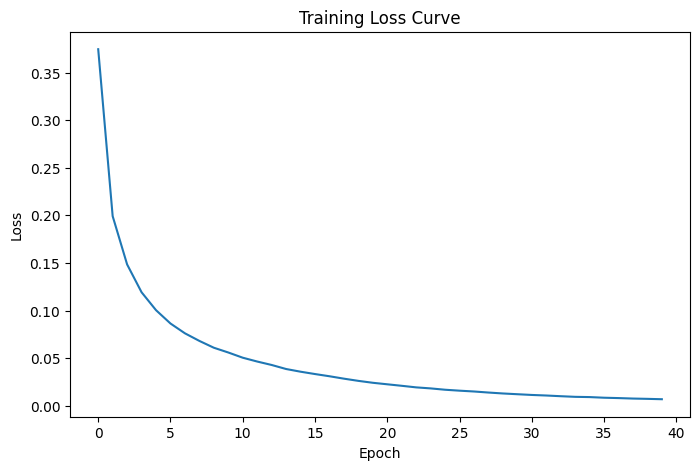

In [26]:
plt.figure(figsize=(8,5))

plt.plot(losses)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("Training Loss Curve")

plt.show()

Evaluating the Test Accuracy

In [27]:
test_acc = accuracy(X_test, y_test)

print("Test Accuracy:", test_acc)

Test Accuracy: 0.98


Predictions

In [28]:
test_probs = forward(X_test)

test_predictions = np.argmax(test_probs, axis=1)

Misclassified Images

In [29]:
misclassified = np.where(test_predictions != y_test)[0]

print("Number of misclassified images:", len(misclassified))

Number of misclassified images: 200


Plotting the Misclassified Images

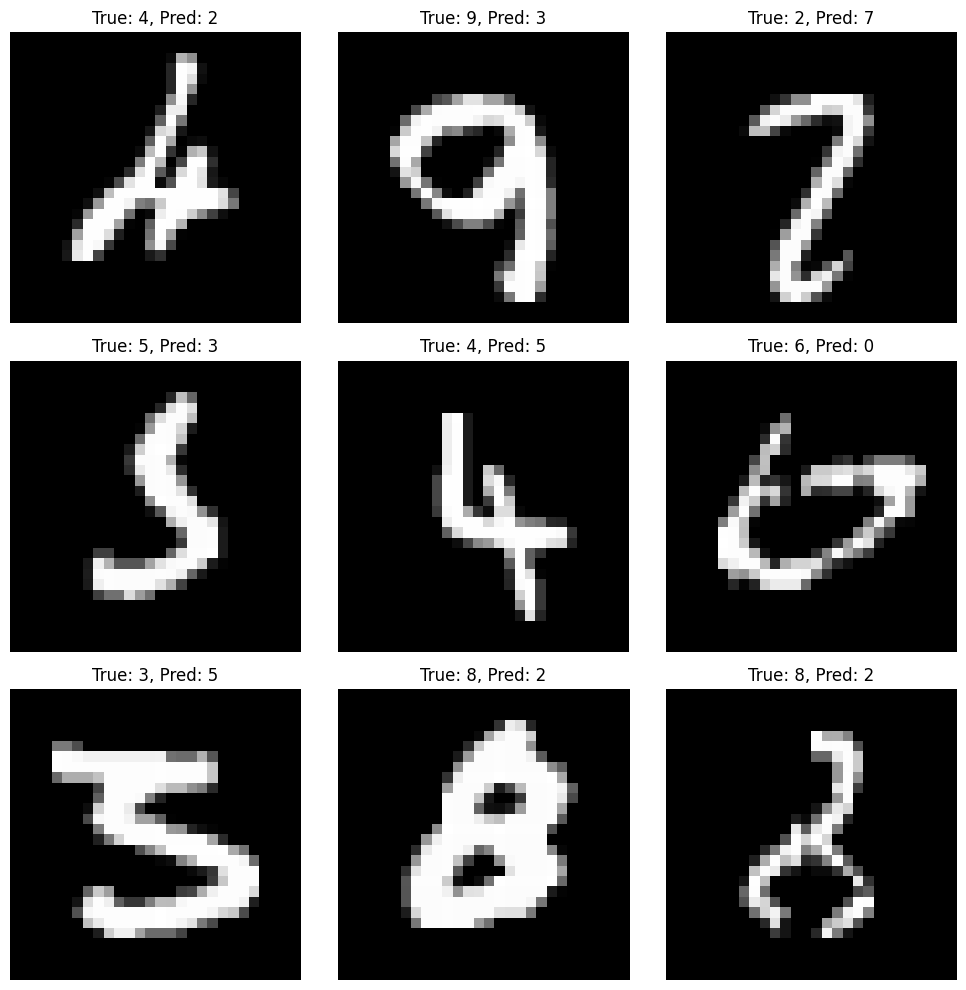

In [30]:
plt.figure(figsize=(10,10))

for i in range(9):

    idx = misclassified[i]

    image = X_test[idx].reshape(28,28)

    true_label = y_test[idx]

    pred_label = test_predictions[idx]

    plt.subplot(3,3,i+1)

    plt.imshow(image, cmap='gray')

    plt.title(f"True: {true_label}, Pred: {pred_label}")

    plt.axis('off')

plt.tight_layout()

plt.show()